<div >
<img src = "../banner.jpg" />
</div>

<a target="_blank" href="https://colab.research.google.com/github/ignaciomsarmiento/BDML_202601/blob/main/Lecture15/02_LDA.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


# Modelado de tópicos o temas 

## Ejemplo comentarios en we8there

Para estudiar la factorización de texto, pasaremos de la política a los restaurantes. Contamos con 6166 reseñas, con una extensión promedio de 90 palabras por reseña, del ya desaparecido sitio web de viajes `we8there.com`. 

In [45]:
data("we8there", package = "textir")

Una característica útil de estas reseñas es que contienen texto y una calificación multidimensional sobre la experiencia general, el ambiente, la comida, el servicio y la relación calidad-precio. Cada aspecto se califica en una escala de cinco puntos, donde 1 indica pésimo y 5 indica excelente. 

Por ejemplo, un usuario envió una reseña muy positiva para Waffle House #1258 en Bossier City, Luisiana: 

Waffle House #1258 in Bossier City, Louisiana:

*I normally would not revue a Waffle House but this one deserves it. The workers, Amanda, Amy, Cherry, James and J.D. were the most pleasant crew I have seen. While it was only lunch, B.L.T. and chili, it was great. The best thing was the 50’s rock and roll music, not to loud not to soft. This is a rare exception to what you all think a Waffle House is. Keep up the good work.*

*Overall: 5, Atmosphere: 5, Food: 5, Service: 5, Value: 5.*



Otro usuario encontró que Sartin's Seafood, no es muy bueno:

Sartin’s Seafood in Nassau Bay, Texas,

*Had a very rude waitress and the manager wasn’t nice either.*
*Overall: 1, Atmosphere: 1, Food: 1, Service: 1, Value: 5.*

In [46]:
x <- we8thereCounts
x[1,x[1,]!=0]

even though larg portion  mouth water     red sauc    babi back     back rib 
           1            1            1            1            1            1 
chocol mouss veri satisfi 
           1            1

### PCA

In [47]:
pca <- prcomp(x, scale=TRUE) # cuidado demora mucho

In [48]:
tail(sort(pca$rotation[,1]))

food great     staff veri     excel food high recommend     great food 
   0.007386860    0.007593374    0.007629771    0.007821171    0.008503594 
    food excel 
   0.008736181

In [49]:
tail(sort(pca$rotation[,4]))

order got after minut  never came   ask check readi order drink order 
 0.05918712  0.05958572  0.06099509  0.06184512  0.06776281  0.07980788

### LDA

#### Aside: Ejemplo paso a paso

En este ejemplo vamos a asumir que hay 3 (D), que contienen 3 temas (K) y 7 (V) palabras

- Paso 1: Definir el vocabulario

In [50]:
set.seed(123)

vocabulario <- c("gato", "perro", "vacuna", "hospital", "dinero", "banco", "impuestos")
V <- length(vocabulario)
V

[1] 7

- Paso 2: Definir las distribuciones de palabras por tópico (φ)

Estas salen de una Dirichlet, mas sobre esto abajo

In [51]:
# Cada vector debe tener longitud igual al vocabulario

phi_1 <- c(0.4, 0.4, 0.05, 0.05, 0.03, 0.03, 0.04)  # Animales
phi_2 <- c(0.05, 0.05, 0.4, 0.4, 0.03, 0.03, 0.04)  # Salud
phi_3 <- c(0.05, 0.05, 0.05, 0.05, 0.35, 0.35, 0.10)  # Economía

# Guardamos las distribuciones en una lista
phi <- list(phi_1, phi_2, phi_3)


phi

[[1]]
[1] 0.40 0.40 0.05 0.05 0.03 0.03 0.04

[[2]]
[1] 0.05 0.05 0.40 0.40 0.03 0.03 0.04

[[3]]
[1] 0.05 0.05 0.05 0.05 0.35 0.35 0.10

- Paso 3: Definir mezcla de tópicos del documento (θ)

Ahora si veamos como funciona la Dirichlet. Esta distribución es una de las pocas distribuciones que modela directamente vectores de probabilidades. Es decir, vectores cuyas componentes:

- son no negativas,

- y suman exactamente 1.

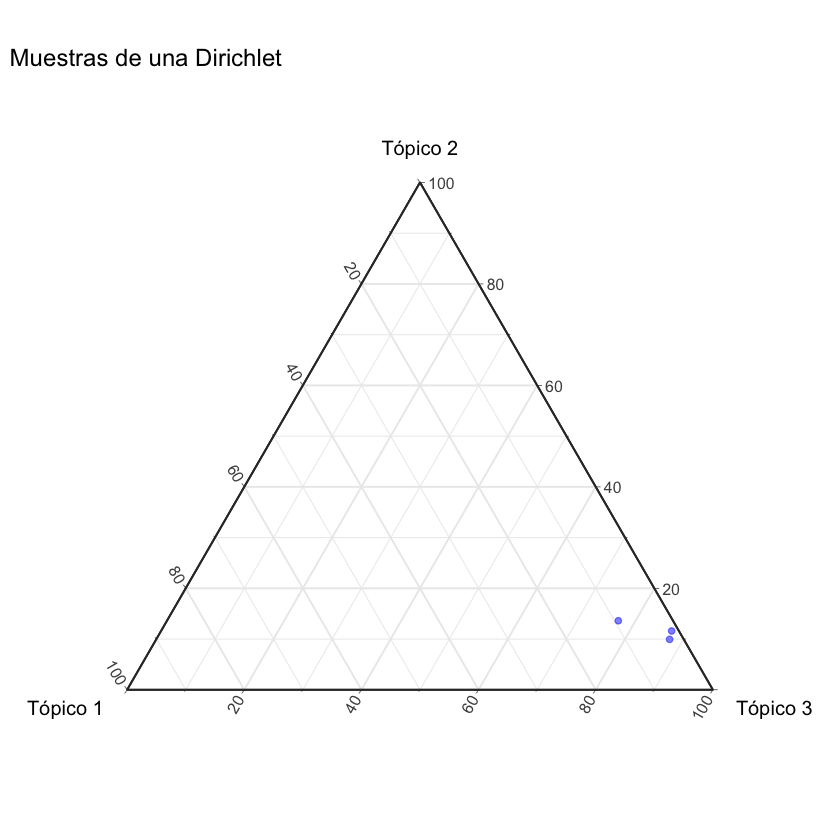

In [56]:

p_load("ggtern")
p_load("MCMCpack")

# Número de muestras
set.seed(123)
D <- 3 #numero de documentos

# Parámetros de la Dirichlet
alpha <- c(1, 1, 20)  # K=3

# Generar muestras
samples <- rdirichlet(D, alpha)
df <- data.frame(Topic1 = samples[,1], Topic2 = samples[,2], Topic3 = samples[,3])

# Graficar puntos de masa
ggtern(data = df, aes(x = Topic1, y = Topic2, z = Topic3)) +
  geom_point(alpha = 0.5, color = "blue", size = 1.5) +
  theme_bw() +
  labs(title = "Muestras de una Dirichlet",
       x = "Tópico 1", y = "Tópico 2", z = "Tópico 3")


In [58]:
df

Topic1,Topic2,Topic3
<dbl>,<dbl>,<dbl>
0.01245440,0.11590329,0.8716423
0.02417974,0.09938618,0.8764341
0.09341521,0.13609342,0.7704914


In [59]:
theta_d <- c(df[1,1], df[1,2], df[1,3])  # de arriba

theta_d

[1] 0.0124544 0.1159033 0.8716423

- Paso 4: Número de palabras en el documento

In [60]:

N <- 10


- Paso 5: Generar los tópicos z_1, ..., z_N

In [61]:


z <- sample(1:3, size = N, replace = TRUE, prob = theta_d)

z

[1] 3 3 3 2 2 3 3 3 3 3

- Paso 6: Generar palabras según los tópicos

In [62]:

w <- character(N)
for (n in 1:N) {
  w[n] <- sample(vocabulario, size = 1, prob = phi[[z[n]]])
}

# Resultado: palabras generadas
print(w)

 [1] "banco"    "banco"    "banco"    "hospital" "vacuna"   "dinero"  
 [7] "dinero"   "banco"    "banco"    "banco"   


- Paso 7: Bag of Words (conteo por palabra)

In [63]:


bow <- table(factor(w, levels = vocabulario))
print(bow)



     gato     perro    vacuna  hospital    dinero     banco impuestos 
        0         0         1         1         2         6         0 


#### Ingenieria reversa

Hasta ahora, simulamos documentos **generando** palabras. Pero en la realidad en la pratica

* Un corpus de documentos reales → textos observados.
* Una representación en BoW o DTM.


Lo que buscamos es inferir los **parámetros** del modelo:

  * Las mezclas de tópicos por documento $\theta_d$,
  * Las distribuciones de palabras por tópico $\phi_k$,
  * Las asignaciones de tópicos $z_{d,n}$ para cada palabra.

Es la ingenieria reversa de MLE: queremos encontrar los parámetros que hacen más **verosímil** (más probable) haber observado nuestros documentos.


$$
\max_{\theta, \phi} \ p(\text{documentos} \mid \theta, \phi)
$$

Pero en LDA no observamos los $z_{d,n}$, ni $\theta$, ni $\phi$. 

**Solo observamos las palabras.**

El problema a resolver es la siguiente verosimilitud:

$$
p(\mathbf{w} \mid \alpha, \beta) = \int \sum_{\mathbf{z}} p(\mathbf{w}, \mathbf{z}, \theta, \phi \mid \alpha, \beta) \ d\theta \ d\phi
$$

Este término **no se puede calcular exactamente**: la suma sobre todas las posibles asignaciones de tópicos $\mathbf{z}$ es **exponencial**.

¿Por qué es "exponencial"?

Porque si: hay $N$ palabras en total en el corpus,  y cada palabra puede tener **uno de $K$ tópicos**, entonces hay: $K^N$ posibles combinaciones de asignaciones de tópicos. Ejemplo: supongamos

* 2 documentos, cada uno con 10 palabras → $N = 20$,
* 3 posibles tópicos → $K = 3$

Entonces hay:

$$
3^{20} = 3,486,784,401
$$

combinaciones posibles de $\mathbf{z}$. 

Entonces

* No podemos **sumar sobre todas** esas posibilidades explícitamente.
* Por eso necesitamos métodos que **aproximen esa suma**:


En la practica hay varios métodos de **inferencia aproximada**, que estiman los parámetros.

Los dos más comunes:

1. **Gibbs Sampling** (una forma de MCMC)
2. **Variational Inference** (una versión determinista, más rápida)


### Regreso al ejemplo de `we8there`

Vamos a usar `maptpx` de Matt Taddy. El algoritmo esta descipto ["On Estimation and Selection for Topic Models"](https://arxiv.org/pdf/1109.4518), e implementa "Topic Posterior Estimation" usando inferiencia variacional y nos aproxima una solución a:

$$
p(\mathbf{w} \mid \alpha, \beta) 
$$

In [64]:
p_load("maptpx") # para modelar topicos

x <- as.simple_triplet_matrix(we8thereCounts) #Convierte a formato sparse
# Es una estructura sparse  que representa solo los elementos distintos de cero (non-sparse), usando tres vectores:
# i: los índices de fila
# j: los índices de columna
#v: los valores (conteos)

In [65]:
tpc <- topics(x,K=10) 


Estimating on a 6166 document collection.
Fitting the 10 topic model.
log posterior increase: 4441.8, 461.4, 101.5, 57.4, 51, 19.2, 26.2, 15.3, 15.4, 11.7, 6.7, 12.2, 8, 10.1, 4.8, 5.3, 3.2, 6.6, 2.8, 7, 3.6, 3.9, 6.7, 5.5, 8.6, 5, 11, 10.3, 12, 7.9, 12.1, 9, 8.8, 13.9, 8.6, 7.3, 6.1, 4.9, 4.3, 12, 11.1, 8.7, 3.2, 2.8, 5.1, 1.9, 2.6, 2.4, 4.9, 2.9, 1.5, 2.5, 4.7, 1.7, 0.9, 1.4, 0.7, 2.5, 2.2, 1.7, 1, 1.3, 1.5, 2, 0.8, 1.7, 0.5, 0.2, 0.5, 0.6, 0.9, 3.9, 0.5, 0.6, 0.4, 0.2, 0.8, 0.2, 1.4, 0.3, 0.5, 0.6, done.


Podemos comparar multiples K, para determinar el número óptimo de tópicos

In [66]:
tpcs <- topics(x,K=5*(1:5), verb=1)


Estimating on a 6166 document collection.
Fit and Bayes Factor Estimation for K = 5 ... 25
log posterior increase: 2853.9, 327.1, 85.3, 36.7, 25.9, 19.9, 13.8, 11.6, 9.6, 11.4, 20.3, 7.1, 3.9, 8.3, 4, 5.9, 2.4, 3.8, 4.8, 5.3, 3.8, 4.5, 4, 3.8, 2.1, 2, 4.8, 4.5, 2.5, 4.3, 7, 4.9, 9.3, 2.9, 9.9, 3.8, 6.2, 7.3, 3.8, 6, 7.9, 7.4, 7.2, 4, 5.6, 8, 14.3, 11.5, 17.6, 14.8, 14.1, 14.4, 9.5, 7.1, 5.4, 5.8, 2.4, 2.5, 1.5, 1.1, 1.9, 2.9, 2.8, 3.1, 1, 0.8, 0.4, 1.9, 1.3, 0.8, 0.8, 1.1, 1, 2.2, 1, 0.7, 0.4, 0.4, 0.4, 2, 0.4, 0.7, 0.2, 0.3, 2.2, 0.4, 0.3, 0.1, 0.2, done.
log BF( 5 ) = 79521.94
log posterior increase: 4626.7, 197.4, 53, 24.9, 19, 9.3, 7.4, 4.6, 5.2, 3.4, 2.3, 1.7, 0.8, 0.6, 0.9, 0.5, 0.8, 2.6, 2.7, 1, 0.5, 0.3, 1.1, 0.5, 0.6, 0.7, 1.3, 0.2, done.
log BF( 10 ) = 87157.28
log posterior increase: 3445, 170.2, 49.8, 23.6, 14.1, 31.4, 16.2, 4.8, 6.6, 5.5, 1.9, 5.9, 4, 2.5, 1.8, 2.1, 1.3, 0.7, 3.6, 1.1, 1.3, 0.7, 0.9, 1.1, 1.8, 1.3, 0.8, 1, 0.3, 0.7, 0.4, 1.2, 0.7, 0.8, 0.1, done.
log BF( 

El Bayes Factor aqui se refiere a 



$$
 \exp\left(- \text{BIC}\right)  \approx p(\mathbf{w} \mid \alpha, \beta)
$$

entonces:

$$
\log p(\mathbf{w} \mid \alpha, \beta) \approx - \text{BIC}
$$

Entonces si nosotros buscabamos minimizar el BIC, vamos a quere maximizar el BF.

*Aside*: el BIC aqui va a ser

$$
\text{BIC} =  \log \hat{L} - \frac{1}{2} \left[ K(V - 1) + D(K - 1) \right] \cdot \log(n)
$$

* $\hat{L}$: log-likelihood del modelo (`mod$loglik` en `maptpx`)
* $V$: número de palabras en el vocabulario
* $D$: número de documentos
* $K$: número de tópicos
* $n$: número total de palabras en el corpus


La maximización del Bayes Factor en `maptpx` encuentra un valor de $K$ que funciona bien para una variedad de tareas posteriores, aunque a veces tiende a seleccionar un $K$ **más pequeño del que nos gustaría** para fines de *storytelling*

**Como se relaciona con otras medidas?**

##### Perplexity

La **perplejidad** (perplexity) es una transformación de la log-verosimilitud, usada como medida de **cuán bien el modelo predice nuevas palabras**.

Se define como:

$$
\text{Perplexity}(\mathbf{w}) = \exp\left( - \frac{1}{N} \log p(\mathbf{w}) \right)
$$

* Cuanto **más baja**, **mejor el modelo predice**.
* Se puede calcular sobre un conjunto de test → mide **poder predictivo**.

##### Coherence
* **Coherencia** mide **cuán interpretables y temáticamente consistentes** son los tópicos. Lo hace calculado qué tan frecuentemente **las palabras más probables de un tópico coocurren en los mismos documentos**. Si las palabras clave de un tópico tienden a aparecer juntas, decimos que el tópico es **coherente**.

* No depende de la log-verosimilitud ni del Bayes factor.
* Se calcula a partir de:

  * las palabras más frecuentes de cada tópico,
  * y su coocurrencia en los documentos.

* Mide si los tópicos "tienen sentido" según cómo las palabras aparecen juntas en los textos.

Formula: 
* Tópico $k$ tiene palabras $w_1, w_2, \dots, w_M$
* Cada $w_i$ es una palabra del vocabulario (por ejemplo, las n más probables según $\phi_k$)

Entonces:

$$
\text{Coherencia}(k) = \sum_{i < j} \log \left( \frac{D(w_i, w_j) + \epsilon}{D(w_j)} \right)
$$

donde:

* $D(w_j)$: número de documentos que contienen la palabra $w_j$
* $D(w_i, w_j)$: número de documentos que contienen ambas $w_i$ y $w_j$
* $\epsilon$: pequeño valor para evitar log(0), usualmente 1

*Ejemplo*: 
Supongamos que un tópico tiene como palabras más probables:

$$
\text{"hospital", "médico", "enfermera", "paciente"}
$$

Estas palabras suelen aparecer juntas en los documentos → el tópico es coherente.

Ahora imagina:

$$
\text{"hospital", "perro", "impuestos", "fútbol"}
$$

Estas palabras no aparecen juntas normalmente → el tópico es incoherente.

##### Interpretación

La interpretación de los tópicos se realiza de manera similar a como se hace con PCA

Podemos comenzar observando las "palabras principales" de cada tópico.

Pero para que esto sea útil, hay que tener cuidado con el criterio que se usa para ordenar las palabras consideradas "principales".

Si las ordenás por la **probabilidad de palabra en el tópico** ($\phi_{kj}$), terminarás con palabras que son frecuentes en el tópico $k$, pero que también pueden ser comunes en otros tópicos —esto pasa especialmente si eliminaste solo un pequeño conjunto de *stopwords*.

En su lugar, la función `summary()` de `maptpx` ordena las palabras según el **lift**:

$$
\text{lift}_{kj} = \frac{\phi_{kj}}{\bar{x}_j} = \frac{\text{especificidad en el tópico}}{\text{frecuencia global}}
$$

donde $\bar{x}_j$ es la frecuencia promedio de la palabra $j$ en el corpus (es decir, su proporción promedio entre los documentos).

Este **lift** será alto para palabras que son **mucho más frecuentes en el tópico $k$** de lo que son en el lenguaje general del corpus.
Por eso, usar lift ayuda a resaltar palabras **más exclusivas o distintivas del tópico**, y no simplemente comunes en todo el corpus.


* Si $\text{lift}_{kj} > 1$: la palabra es **más característica** del tópico que del corpus.
* Si $\text{lift}_{kj} \ll 1$: es una palabra común (no distintiva).

El lift evita que en los tópicos aparezcan como “principales” palabras genéricas, que aunque sean frecuentes en todos los documentos, **no ayudan a interpretar el tópico en cuestión**.


In [ ]:
summary(tpcs, n=10) 

El primer tópico contiene retroalimentación positiva, y por eso tiene la misma interpretación que el primer componente principal (PC1).

In [ ]:
rownames(tpcs$theta)[order(tpcs$theta[,1], decreasing=TRUE)[1:10]]

Pero los otros tópicos parecen distintos y más interpretables que los factores obtenidos mediante PCA.
Por ejemplo:

El tópico 2 trata sobre tener que esperar,

In [ ]:
rownames(tpcs$theta)[order(tpcs$theta[,2], decreasing=TRUE)[1:10]]

El tópico 3 incluye reseñas positivas de clientes frecuentes.

In [ ]:
rownames(tpcs$theta)[order(tpcs$theta[,3], decreasing=TRUE)[1:10]]

Podemos comparar los **scores de tópicos** (los $\theta$) con las **calificaciones de las reseñas**.

Veamos la **calificación general** en función de los **scores de los documentos** en el primer topico


In [ ]:
boxplot(tpcs$omega[,1] ~ we8thereRatings$Overall, col="gold", xlab="overall rating", ylab="topic 1 score")

Hay claramente una **relación positiva entre el tópico 1 y la calificación general**  que lo que se observaba usando el **primer componente principal (PC1)**. (HW)

y en el segundo vemos algo parecido:

In [ ]:
boxplot(tpcs$omega[,2] ~ we8thereRatings$Overall, col="pink", xlab="overall rating", ylab="topic 2 score")

Estas relaciones sugieren una estrategia de **regresión sobre tópicos** para predecir la **calificación de una reseña** a partir de su **contenido textual**.

#### Prediciendo los ratings en `we8there`

In [ ]:
stars <- we8thereRatings[,"Overall"]

In [ ]:
Xtopics<-as(tpcs$omega, "dMatrix")

#### Lasso temas

In [ ]:
p_load("gamlr")
regtopics.cv <- cv.gamlr(tpcs$omega, stars)

#### Lasso palabras 

In [ ]:
regwords.cv <- cv.gamlr(we8thereCounts, stars)

Resultados

In [ ]:
par(mfrow=c(1,2), mai=c(.3,.6,.7,.1), omi=c(.5,.2,0,0))
plot(regtopics.cv, ylim=c(1,2), xlab="", ylab="")
mtext("topic regression", font=2, line=2)
plot(regwords.cv, ylim=c(1,2), xlab="", ylab="")
mtext("token regression", font=2, line=2)
mtext(side=2, "mean squared error", outer=TRUE, line=0)
mtext(side=1, "log lamba", outer=TRUE, line=1)